In [1]:
import Labber
import os
import sys
from fitTools.utilities import Watt2dBm, dBm2Watt, VNA2dBm

from twpa_tune_up_helper_functions import *

In [2]:
ref_data_file = r"G:\Shared drives\Labber\Data\2025\04\Data_0407\NBRL1A_TWPA_OFF_ref_2.hdf5"
labber_data_file = r"G:\Shared drives\Labber\Data\2025\04\Data_0407\NBRL1A_TWPA_ON_SA_sweep_3.hdf5"
#labber_data_file = r"G:\Shared drives\Labber\Data\2025\04\Data_0407\NBRL1A_TWPA_SA_Sweep_Higher_Power.hdf5"

lf = Labber.LogFile(labber_data_file)

In [3]:
std_highSNR = 1.15 # cut off point for determining high SNR
cutOff_around_SA_peak = 40e3 # Hz

In [4]:
SA_channel_name = lf.getLogChannels()[0]["name"]
signal = lf.getData(name = SA_channel_name)
linsig = dBm2Watt(signal)


In [5]:
repeated = len(lf.getStepChannels()[0]["values"])
power_range = len(lf.getStepChannels()[1]["values"])
freq_range = len(lf.getStepChannels()[2]["values"])


power_channel_name = lf.getStepChannels()[1]["name"]
freq_channel_name = lf.getStepChannels()[2]["name"]
SA_channel_name = lf.getLogChannels()[0]["name"]

pump_power = lf.getData(name = power_channel_name)
pump_freq = lf.getData(name = freq_channel_name)

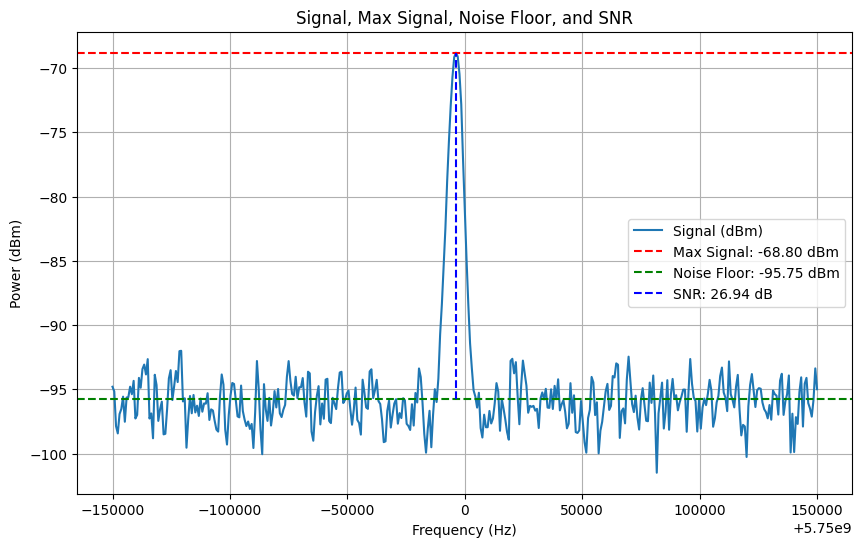



========== REFERENCE DATA ==========
Average SNR is 26.942659955808026 dBm
Average Max Signal is -68.80333333333333 dBm
Average of the noise floor is -95.74599328914135 dBm





In [6]:
SAxdata, SAydata = lf.getTraceXY(y_channel=SA_channel_name) # gives last trace from SA

plt.rcParams['savefig.facecolor']='white'

ref_snr, ref_max_signal, ref_noise_floors = get_reference_data_SNR(ref_data_file,cutOff_around_SA_peak,plot=True)

print("\n\n"+"="*10+" REFERENCE DATA "+"="*10)
print("Average SNR is {} dBm".format(ref_snr))
print("Average Max Signal is {} dBm".format(ref_max_signal))
print("Average of the noise floor is {} dBm".format(ref_noise_floors))
print("="*40+"\n\n\n")

In [9]:
%matplotlib qt

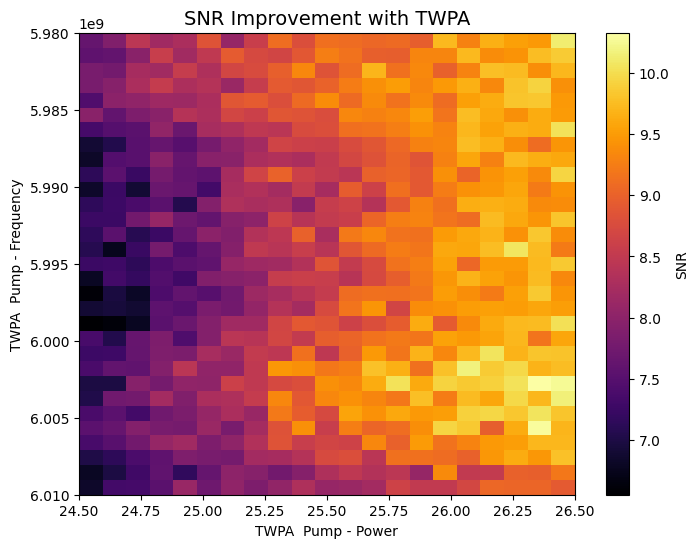

In [7]:
get_SNR_space_plot(signal,repeated, freq_range, power_range, pump_freq,
                    pump_power, SAxdata, ref_snr, cutOff=cutOff_around_SA_peak,
                    xlabel=power_channel_name,
                    ylabel=freq_channel_name, zlabel='SNR', 
                    fig_type=".png", path="figures",plot=False,)




In [10]:
print("\n\n"+"="*10+" TWPA Optimal Parameters"+"="*10)
get_high_SNR_regions(signal,repeated, freq_range, power_range, pump_freq,
                        pump_power, SAxdata, ref_snr, cutOff=cutOff_around_SA_peak,
                        std_highSNR=std_highSNR)





========== TWPA Optimal Parameters==========
SNR = 9.788 for Power = 26.5 dBm and Frequency = 6008000000.0 Hz
SNR = 9.714 for Power = 26.4 dBm and Frequency = 6007000000.0 Hz
SNR = 9.713 for Power = 26.5 dBm and Frequency = 6007000000.0 Hz
SNR = 9.933 for Power = 26.0 dBm and Frequency = 6006000000.0 Hz
SNR = 9.847 for Power = 26.1 dBm and Frequency = 6006000000.0 Hz
SNR = 10.297 for Power = 26.4 dBm and Frequency = 6006000000.0 Hz
SNR = 9.700 for Power = 26.5 dBm and Frequency = 6006000000.0 Hz
SNR = 9.912 for Power = 26.1 dBm and Frequency = 6005000000.0 Hz
SNR = 9.951 for Power = 26.2 dBm and Frequency = 6005000000.0 Hz
SNR = 9.837 for Power = 26.3 dBm and Frequency = 6005000000.0 Hz
SNR = 10.062 for Power = 26.4 dBm and Frequency = 6005000000.0 Hz
SNR = 9.820 for Power = 26.5 dBm and Frequency = 6005000000.0 Hz
SNR = 9.779 for Power = 25.9 dBm and Frequency = 6004000000.0 Hz
SNR = 9.742 for Power = 26.1 dBm and Frequency = 6004000000.0 Hz
SNR = 9.971 for Power = 26.3 dBm and Freq

array([[2.65000000e+01, 6.00800000e+09, 9.78763185e+00],
       [2.64000000e+01, 6.00700000e+09, 9.71371451e+00],
       [2.65000000e+01, 6.00700000e+09, 9.71337592e+00],
       [2.60000000e+01, 6.00600000e+09, 9.93347500e+00],
       [2.61000000e+01, 6.00600000e+09, 9.84687443e+00],
       [2.64000000e+01, 6.00600000e+09, 1.02973991e+01],
       [2.65000000e+01, 6.00600000e+09, 9.70012508e+00],
       [2.61000000e+01, 6.00500000e+09, 9.91177240e+00],
       [2.62000000e+01, 6.00500000e+09, 9.95143701e+00],
       [2.63000000e+01, 6.00500000e+09, 9.83687630e+00],
       [2.64000000e+01, 6.00500000e+09, 1.00621722e+01],
       [2.65000000e+01, 6.00500000e+09, 9.82042441e+00],
       [2.59000000e+01, 6.00400000e+09, 9.77894108e+00],
       [2.61000000e+01, 6.00400000e+09, 9.74237738e+00],
       [2.63000000e+01, 6.00400000e+09, 9.97107468e+00],
       [2.64000000e+01, 6.00400000e+09, 9.71141445e+00],
       [2.65000000e+01, 6.00400000e+09, 1.01557324e+01],
       [2.58000000e+01, 6.00300

In [ ]:

get_gain_space_plot(signal,repeated, freq_range, power_range, pump_freq,
                    pump_power, SAxdata, ref_max_signal, cutOff=cutOff_around_SA_peak,
                    xlabel=power_channel_name,
                    ylabel=freq_channel_name, zlabel=SA_channel_name,
                    fig_type=".png", path="figures")